## Simple Linear Regression only x = age and y = salary 

In [181]:
import random
import matplotlib.pyplot as plt
x_age = [10,20,30,40,50,60 ,90]


y_salary = [200,400,600,800,1000,1200 , 400]


def random_split(x_age , y_salary , test_size=0.5):


    total_size = len(x_age)

    test_size = int(total_size * test_size)
    train_size = total_size - test_size

    x_train_index = random.sample(range(total_size), train_size)

    x_train_age =[]
    for i in x_train_index:
        x_train_age.append(x_age[i])
    
   
    y_train_salary = []
    for i in x_train_index:
        y_train_salary.append(y_salary[i])

    x_test_index = []
    for i in range(total_size):
        if i not in x_train_index:
            x_test_index.append(i)


    x_test_age = []
    for i in x_test_index:
        x_test_age.append(x_age[i])

    y_test_salary = []
    for i in x_test_index:
        y_test_salary.append(y_salary[i])

    print(x_train_index)
    print(x_test_index)

    return x_train_age, y_train_salary, x_test_age, y_test_salary



def simple_linear_regression(x_train, y_train):
    
    n = len(x_train)
    sum_x = sum(x_train)
    sum_y = sum(y_train)

    sum_x_squared = sum([x**2 for x in x_train])
    sum_xy = sum([x*y for x,y in zip(x_train, y_train)])

    m = (n*sum_xy - sum_x*sum_y) / (n*sum_x_squared - sum_x**2)
    c = (sum_y - m*sum_x) / n
   
    return m, c

def predict(age):
    x_train_age, y_train_salary, x_test_age, y_test_salary = random_split(x_age, y_salary , test_size = 0.3)
    m, c = simple_linear_regression(x_train_age, y_train_salary)

    plt.scatter(x_train_age, y_train_salary, color='blue', label='Training Data')
    plt.plot(x_train_age, [m * x + c for x in x_train_age], color='red', label='Regression Line')
    plt.xlabel('Age')
    plt.ylabel('Salary')
    plt.show()

    print(m , c)
    return m*age + c




[0, 4, 6, 2, 1]
[3, 5]


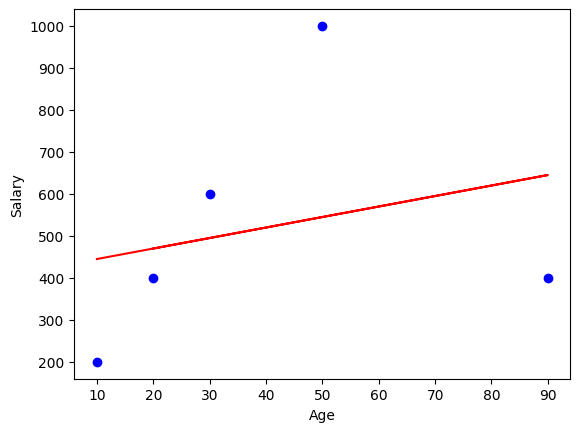

2.5 420.0


532.5

In [182]:
predict(45)

## MultiLinear Regression

In [183]:
x_data = {'x1':[4,9,8,8,7,5],
          'x2':[1,2,3,1,1,0],
          'x3':[3,1,2,1,4,2]}


y_data = [52,51,50,52,70,60]

print(x_data['x1'])



[4, 9, 8, 8, 7, 5]


In [184]:
import random

def random_split(x_data, y_data, test_size=0.2):

    total_size = len(x_data['x1'])

    test_size = int(total_size * test_size)
    train_size = total_size - test_size

    x_train_index = random.sample(range(total_size), train_size)

    x_train = {}
    for key in x_data:
        x_train[key] = []
        for i in x_train_index:
            x_train[key].append(x_data[key][i])

    y_train = []
    for i in x_train_index:
        y_train.append(y_data[i])

    x_test_index = []
    for i in range(total_size):
        if i not in x_train_index:
            x_test_index.append(i)

    x_test = {}
    for key in x_data:
        x_test[key] = []
        for i in x_test_index:
            x_test[key].append(x_data[key][i])

    y_test = []
    for i in x_test_index:
        y_test.append(y_data[i])

    print(x_train_index)
    print(x_test_index)

    return x_train, y_train, x_test, y_test






In [185]:
import matplotlib.pyplot as plt

def multi_linear_regression(x_data, y_data):

    x1_mean = sum(x_data['x1']) / len(x_data['x1'])
    x2_mean = sum(x_data['x2']) / len(x_data['x2'])
    x3_mean = sum(x_data['x3']) / len(x_data['x3'])
    y_mean = sum(y_data) / len(y_data)

    numerator_m1 = 0
    denominator_m1 = 0

    for i in range(len(y_data)):
        numerator_m1 += (x_data['x1'][i] - x1_mean) * (y_data[i] - y_mean)
        denominator_m1 += (x_data['x1'][i] - x1_mean) ** 2
    m1 = numerator_m1 / denominator_m1

    numerator_m2 = 0
    denominator_m2 = 0
    for i in range(len(y_data)):
        numerator_m2 += (x_data['x2'][i] - x2_mean) * (y_data[i] - y_mean)
        denominator_m2 += (x_data['x2'][i] - x2_mean) ** 2
    m2 = numerator_m2 / denominator_m2

    numerator_m3 = 0
    denominator_m3 = 0
    for i in range(len(y_data)):
        numerator_m3 += (x_data['x3'][i] - x3_mean) * (y_data[i] - y_mean)
        denominator_m3 += (x_data['x3'][i] - x3_mean) ** 2
    m3 = numerator_m3 / denominator_m3

    c = y_mean - (m1 * x1_mean + m2 * x2_mean + m3 * x3_mean)

    return [m1, m2, m3], c


def predict(x1, x2, x3):
    x_train, y_train, x_test, y_test = random_split(x_data, y_data, test_size=0.5)
    m, c = multi_linear_regression(x_train, y_train)

    # plt.scatter(x_train['x1'] , x_train['x2'] , x_train['x3'], y_train, color='blue', label='Training Data')
    plt.scatter(x_train['x1'] , y_train, color='blue', label='Training Data')
    plt.plot(x_train['x1'], [m[0] * x + c for x in x_train['x1']], color='red', label='Regression Line')
    
    plt.scatter(x_train['x2'] , y_train, color='blue', label='Training Data')
    plt.plot(x_train['x2'], [m[0] * x + c for x in x_train['x2']], color='red', label='Regression Line')

    plt.scatter(x_train['x3'] , y_train, color='blue', label='Training Data')
    plt.plot(x_train['x3'], [m[0] * x + c for x in x_train['x3']], color='red', label='Regression Line')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Multi-Linear Regression')
   
    plt.show()
    print(m, c)
    return m[0]*x1 + m[1]*x2 + m[2]*x3 + c

[2, 4, 3]
[0, 1, 5]


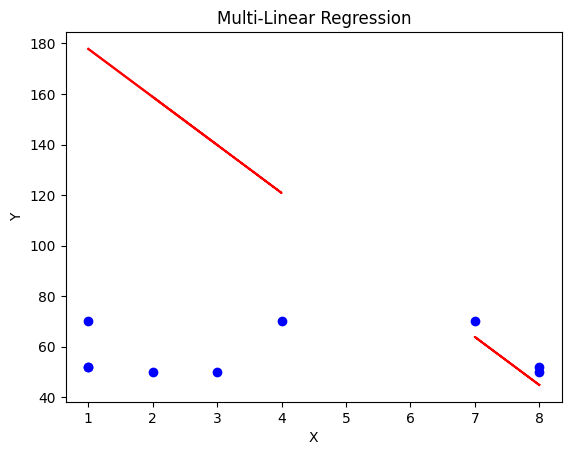

[-18.999999999999996, -5.5, 6.571428571428572] 196.83333333333331
Prediction: 34.547619047619065


In [186]:
print("Prediction:", predict(9, 2, 3))

In [ ]:
docker volume create n8n_data && \
